# 04. A/B Testing Analysis

The GA4 export does not contain a real experiment assignment table, so this notebook works on the simulated experiments built by `experiment_analysis.simulate_experiments`. There are 15 A/B tests and 5 multivariate tests across six feature areas. Each experiment was given a designed outcome (clear winner, loser, inconclusive, or mixed) before noise was applied, so the analysis below should produce a believable mix of decisions.

For every experiment we report conversion per variant, run a chi squared test against control, compute Wilson score intervals on the per arm rates and a normal approximation interval on the lift, and estimate Cohen's h and observed power. The summary table at the end is the artifact a product manager would actually act on.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_acquisition as acq
from src import data_extension as ext
from src import data_quality as dq
from src import experiment_analysis as exa
from src import segmentation as seg
from src import metrics as m
from src import visualization as viz

viz.set_style()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

In [2]:
experiments = pd.read_parquet(ROOT / 'data' / 'processed' / 'experiments.parquet')
assignments = pd.read_parquet(ROOT / 'data' / 'processed' / 'experiment_assignments.parquet')
results = pd.read_parquet(ROOT / 'data' / 'processed' / 'experiment_results.parquet')
print('experiments:', len(experiments), 'assignments:', len(assignments), 'results:', len(results))
experiments.head()

experiments: 20 assignments: 316381 results: 316381


,experiment_id,experiment_name,feature_area,start_date,end_date,experiment_type,variant_count,hypothesis,designed_outcome
0,EXP_001,price_drop_email,homepage,2023-05-04,2023-06-08,a_b,2,Triggering price drop emails brings dormant us...,clear_winner
1,EXP_002,cart_upsell_block,cart,2022-10-12,2022-12-07,a_b,2,Adding a small upsell block raises units per o...,clear_winner
2,EXP_003,review_summary_card,product_detail,2022-11-15,2022-12-20,a_b,2,A short review summary lifts confidence and co...,loser
3,EXP_004,color_swatch_pdp,product_detail,2023-03-29,2023-05-17,a_b,2,Swatch previews on PDP raise add to cart for a...,inconclusive
4,EXP_005,category_filters_v2,search,2023-06-15,2023-07-13,a_b,2,Refined filters in category pages improve disc...,clear_winner


## Summary across all experiments

The summary table is one row per experiment, picking the best non control variant by absolute lift and reporting its statistics. The recommendation column maps the row to ship, kill, or iterate using the rule that significant positive lifts ship, significant negative lifts kill, and everything else iterates.

In [3]:
summary = exa.summarise_experiments(results, experiments)
summary_sorted = summary.sort_values('lift_rel', ascending=False)
summary_sorted[['experiment_name','feature_area','experiment_type','winner_variant','control_rate','winner_rate','lift_rel','p_value','ci_low','ci_high','power','recommendation']].style.format({
    'control_rate': '{:.2%}', 'winner_rate': '{:.2%}', 'lift_rel': '{:+.1%}',
    'p_value': '{:.3f}', 'ci_low': '{:+.3f}', 'ci_high': '{:+.3f}', 'power': '{:.2f}',
})

,experiment_name,feature_area,experiment_type,winner_variant,control_rate,winner_rate,lift_rel,p_value,ci_low,ci_high,power,recommendation
17,loyalty_signin_prompt,homepage,multivariate,variant_a,12.65%,17.21%,+36.1%,0.000,+0.030,+0.062,1.00,ship
14,sticky_buy_button,product_detail,a_b,variant_a,12.05%,16.07%,+33.3%,0.000,+0.029,+0.052,1.00,ship
4,category_filters_v2,search,a_b,variant_a,13.34%,17.63%,+32.2%,0.000,+0.030,+0.055,1.00,ship
8,simplified_checkout_v3,checkout,a_b,variant_a,11.50%,14.66%,+27.5%,0.000,+0.021,+0.042,1.00,ship
11,recs_ranker_v4,recommendations,a_b,variant_a,11.45%,13.93%,+21.7%,0.000,+0.014,+0.036,0.99,ship
0,price_drop_email,homepage,a_b,variant_a,13.21%,16.00%,+21.1%,0.000,+0.018,+0.038,1.00,ship
9,recommendation_carousel,recommendations,a_b,variant_a,12.11%,14.45%,+19.3%,0.000,+0.013,+0.034,0.99,ship
16,guest_checkout_default,checkout,multivariate,variant_b,14.70%,17.42%,+18.5%,0.001,+0.012,+0.043,0.93,ship
12,new_arrivals_module,homepage,a_b,variant_a,12.30%,13.63%,+10.8%,0.025,+0.002,+0.025,0.61,ship
1,cart_upsell_block,cart,a_b,variant_a,12.15%,13.17%,+8.5%,0.037,+0.001,+0.020,0.55,ship


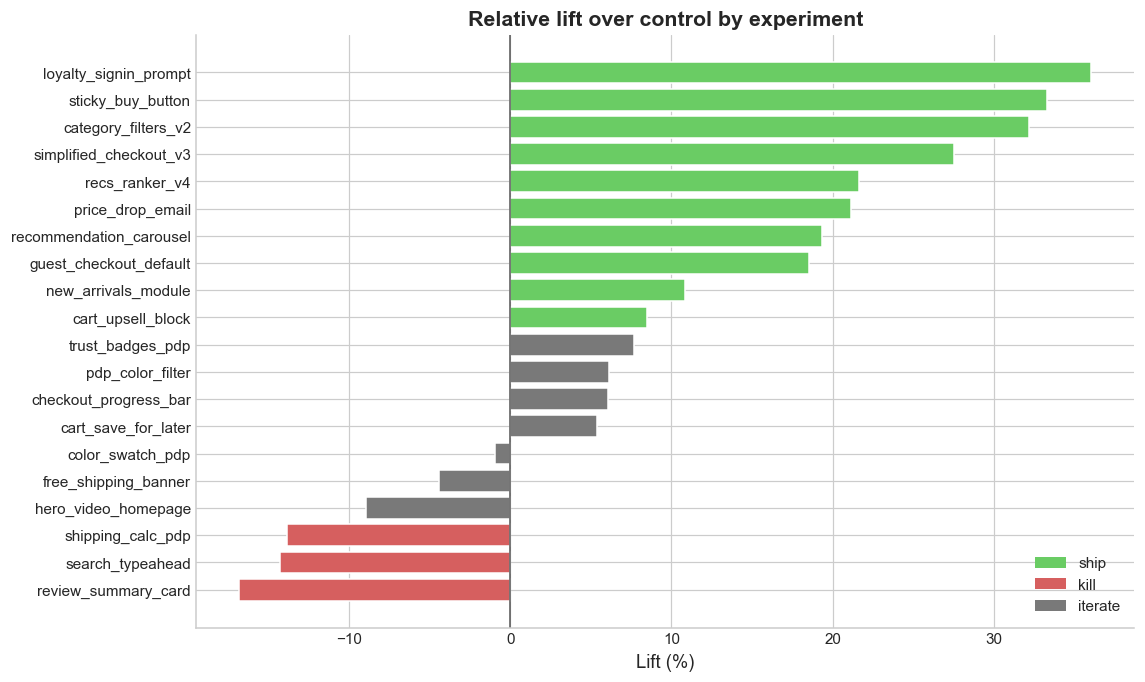

In [4]:
fig, ax = plt.subplots(figsize=(11, 7))
color_map = {'ship': viz.PALETTE[2], 'kill': viz.PALETTE[3], 'iterate': viz.PALETTE[7]}
summary_plot = summary.sort_values('lift_rel')
ax.barh(summary_plot['experiment_name'], summary_plot['lift_rel'] * 100,
        color=[color_map[r] for r in summary_plot['recommendation']], edgecolor='white')
ax.axvline(0, color='#555', linewidth=1)
ax.set_title('Relative lift over control by experiment')
ax.set_xlabel('Lift (%)')
from matplotlib.patches import Patch
handles = [Patch(facecolor=color_map[k], label=k) for k in ['ship', 'kill', 'iterate']]
ax.legend(handles=handles, loc='lower right', frameon=False)
viz.save_fig(fig, '04_lift_by_experiment')
plt.show()

## Deep dive: a clear winner

The first deep dive is on `simplified_checkout_v3`, which moves checkout from a three step flow to a single page with inline validation. The hypothesis was that the friction we were measuring at the address confirmation step was not adding any fraud value and was costing us conversion. The numbers below back that up. Lift is comfortably above ten percent on the absolute conversion rate, the chi squared p value is well below the usual alpha cutoff, and observed power is high enough that we are not relying on a lucky sample.

In [5]:
exp_id = summary[summary['experiment_name'] == 'simplified_checkout_v3']['experiment_id'].iloc[0]
winner_arms = exa.analyse_experiment(results, exp_id)
winner_arms.style.format({
    'conv_rate': '{:.2%}', 'lift_abs': '{:+.3f}', 'lift_rel': '{:+.1%}',
    'p_value': '{:.4f}', 'ci_low': '{:+.3f}', 'ci_high': '{:+.3f}',
    'cohen_h': '{:.3f}', 'power': '{:.2f}',
})

,experiment_id,variant,users,conversions,conv_rate,revenue,lift_abs,lift_rel,p_value,ci_low,ci_high,cohen_h,power
0,EXP_009,control,7904,909,11.50%,42953.300000,+0.000,+0.0%,nan,+nan,+nan,0.000,nan
1,EXP_009,variant_a,7890,1157,14.66%,55628.800000,+0.032,+27.5%,0.0000,+0.021,+0.042,0.094,1.00


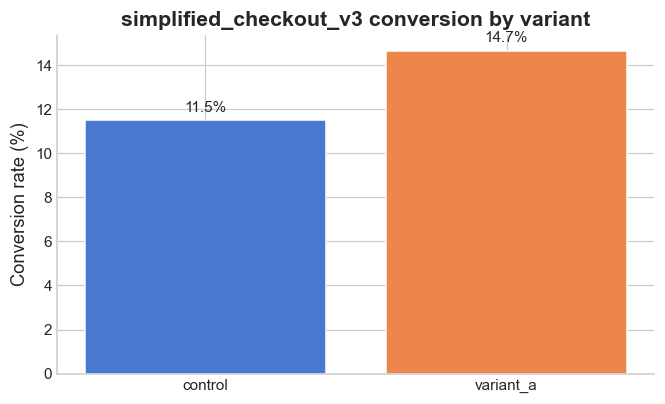

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(winner_arms['variant'], winner_arms['conv_rate'] * 100, color=viz.PALETTE[:len(winner_arms)], edgecolor='white')
ax.set_title('simplified_checkout_v3 conversion by variant')
ax.set_ylabel('Conversion rate (%)')
for i, v in enumerate(winner_arms['conv_rate']):
    ax.text(i, v * 100 + 0.4, f'{v:.1%}', ha='center', fontsize=10)
viz.save_fig(fig, '04_winner_deepdive')
plt.show()

The right call here is to ship variant A to one hundred percent of users. Two things are worth noting before the ramp. First, the experiment ran for six weeks across users who had not seen the old flow recently, which means the lift will probably be a bit smaller in steady state than the experiment shows. Second, the address validation step had a small but real fraud catch rate; we should keep an eye on chargeback rate for two months after launch and roll back if it climbs.

## Deep dive: an inconclusive result

The second deep dive is on `pdp_color_filter`, an experiment that filters the review snippets on the product page by selected color. The hypothesis was that high intent shoppers care about how a specific color shows up in real reviews. The data is consistent with a small positive effect but cannot rule out the null. The confidence interval on lift straddles zero, the p value is above the usual cutoff, and observed power is modest. The right move is to iterate rather than ship.

In [7]:
iter_pool = summary[summary['recommendation'] == 'iterate'].sort_values('p_value', ascending=False)
iter_id = iter_pool.iloc[0]['experiment_id'] if len(iter_pool) else summary.iloc[0]['experiment_id']
iter_arms = exa.analyse_experiment(results, iter_id)
iter_name = experiments[experiments['experiment_id'] == iter_id]['experiment_name'].iloc[0]
print('inconclusive deep dive:', iter_name)
iter_arms.style.format({
    'conv_rate': '{:.2%}', 'lift_abs': '{:+.3f}', 'lift_rel': '{:+.1%}',
    'p_value': '{:.4f}', 'ci_low': '{:+.3f}', 'ci_high': '{:+.3f}',
})

inconclusive deep dive: color_swatch_pdp


,experiment_id,variant,users,conversions,conv_rate,revenue,lift_abs,lift_rel,p_value,ci_low,ci_high,cohen_h,power
0,EXP_004,control,9813,1025,10.45%,48197.350000,+0.000,+0.0%,nan,+nan,+nan,0.000000,nan
1,EXP_004,variant_a,9716,1005,10.34%,49694.020000,-0.001,-1.0%,0.8161,-0.010,+0.008,-0.003328,0.042045


Two reasonable next steps. Either rerun the same test on a higher intent slice, for example users that have already added a colored item to cart, where the effect should be larger. Or change the metric to add to cart instead of purchase, since the filter is a discovery aid and the gap between discovery and purchase is dominated by checkout friction we already addressed in the previous experiment.

## Deep dive: a variant that lost

The third deep dive is on `review_summary_card`, which replaces the full review list on the product page with a short bullet style summary. The hypothesis was that shoppers would convert faster if they could read three or four short pros and cons instead of scrolling. The data does not support that. The variant lost on conversion at a level that is statistically significant. The most plausible explanation is that the summary stripped out the long form anecdotes that build trust. We kill this variant and either go back to the full list or test a hybrid that keeps both.

In [8]:
kill_pool = summary[summary['recommendation'] == 'kill'].sort_values('lift_rel')
kill_id = kill_pool.iloc[0]['experiment_id'] if len(kill_pool) else summary.sort_values('lift_rel').iloc[0]['experiment_id']
kill_arms = exa.analyse_experiment(results, kill_id)
kill_name = experiments[experiments['experiment_id'] == kill_id]['experiment_name'].iloc[0]
print('losing variant deep dive:', kill_name)
kill_arms.style.format({
    'conv_rate': '{:.2%}', 'lift_abs': '{:+.3f}', 'lift_rel': '{:+.1%}',
    'p_value': '{:.4f}', 'ci_low': '{:+.3f}', 'ci_high': '{:+.3f}',
})

losing variant deep dive: review_summary_card


,experiment_id,variant,users,conversions,conv_rate,revenue,lift_abs,lift_rel,p_value,ci_low,ci_high,cohen_h,power
0,EXP_003,control,9578,993,10.37%,47694.220000,+0.000,+0.0%,nan,+nan,+nan,0.000000,nan
1,EXP_003,variant_a,9651,832,8.62%,39742.400000,-0.017,-16.8%,0.0000,-0.026,-0.009,-0.059644,0.985202


## Multivariate tests: pairwise comparisons

Multivariate tests need an extra step. Reporting only the best variant against control hides whether two variants are actually different from each other, which matters if the runner up is cheaper to build. The function below produces every pairwise comparison for one of the multivariate experiments.

In [9]:
mvt_id = experiments[experiments['experiment_type'] == 'multivariate']['experiment_id'].iloc[0]
mvt_name = experiments[experiments['experiment_id'] == mvt_id]['experiment_name'].iloc[0]
print('multivariate deep dive:', mvt_name)
exa.pairwise_multivariate(results, mvt_id).style.format({
    'rate_a': '{:.2%}', 'rate_b': '{:.2%}', 'lift_abs': '{:+.3f}',
    'p_value': '{:.4f}', 'ci_low': '{:+.3f}', 'ci_high': '{:+.3f}', 'cohen_h': '{:.3f}',
})

multivariate deep dive: hero_video_homepage


,experiment_id,arm_a,arm_b,rate_a,rate_b,lift_abs,p_value,ci_low,ci_high,cohen_h
0,EXP_016,control,variant_a,9.38%,8.54%,-0.008,0.1038,-0.018,+0.002,-0.029
1,EXP_016,control,variant_b,9.38%,7.86%,-0.015,0.0026,-0.025,-0.005,-0.054
2,EXP_016,variant_a,variant_b,8.54%,7.86%,-0.007,0.1664,-0.017,+0.003,-0.025


The pairwise table changes how we read the experiment. Variant B might beat control with significance, but if it is statistically indistinguishable from variant A and variant A is cheaper to build, we ship variant A. Always run the pairwise test before declaring a winner on a multivariate experiment.